# Anatomy of a Language Model

Lecture 2 · Anatomy of a Language Model

**Corpus.** Thirty annual reports from the [ECLAC digital repository](https://repositorio.cepal.org), the English editions of the *Economic Survey*, the *Preliminary Overview*, the *Social Panorama*, *Foreign Direct Investment* and *Latin America and the Caribbean in the World Economy*. `assets/build-corpus.py` takes the plain text that the repository keeps beside each PDF, drops running headers, tables, captions and front matter, and writes one sentence per line. The source PDFs are in `assets/.temp`.

Sections 1 and 2 build and train a model from scratch. Sections 3 and 4 run published models. Two of those models are held at once, so a GPU with 40 GB runs all of it and 48 GB is comfortable.

In [1]:
import collections
import math
import re
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset, random_split

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')


def thousands(number: int) -> str:
    return f'{number:,}'.replace(',', ' ')


print(f'Running on {DEVICE}.')

Running on cuda.


## 1. Tokens, training and generation

### The corpus

In [2]:
with open('assets/corpus.txt', encoding='utf-8') as file:
    corpus = file.read()

print(f'{thousands(len(corpus.splitlines()))} sentences, {len(corpus) / 1e6:.2f} MB')
print()
print(*corpus.splitlines()[:3], sep='\n')

57 107 sentences, 10.31 MB

In conclusion, no common or constant pattern can be discerned in terms of the co-occurrence or sequencing of variations in economic growth, investment, national savings and external savings rates.
Because of the interaction between shared factors and specifically national factors, these patterns vary across countries and over time.
Consequently, the application of general theories or econometric findings can lead to erroneous interpretations of growth processes and to oversimplifications that can impair the formulation of successful growth-promoting policies for the region.


### Tokenization

In [3]:
class Tokenizer:

    PIECE = re.compile(r' ?[A-Za-z]+|\d| ?[^\sA-Za-z\d]|\s+')

    def __init__(self, text: str, vocab_size: int) -> None:
        self.merges = self.train(text, vocab_size)
        self.vocab_size = 256 + len(self.merges)
        self.cache: dict[str, tuple[int, ...]] = {}

        self.tokens = {token_id: bytes([token_id]) for token_id in range(256)}
        for (left, right), token_id in self.merges.items():
            self.tokens[token_id] = self.tokens[left] + self.tokens[right]

    @staticmethod
    def apply(symbols: tuple[int, ...], pair: tuple[int, int], new_id: int) -> tuple[int, ...]:
        merged, position = [], 0
        while position < len(symbols):
            here = symbols[position:position + 2]
            if len(here) == 2 and here == pair:
                merged.append(new_id)
                position += 2
            else:
                merged.append(symbols[position])
                position += 1
        return tuple(merged)

    def train(self, text: str, vocab_size: int) -> dict[tuple[int, int], int]:
        counts = collections.Counter(self.PIECE.findall(text))
        words = {piece: tuple(piece.encode('utf-8')) for piece in counts}

        merges: dict[tuple[int, int], int] = {}
        for new_id in range(256, vocab_size):
            pairs: collections.Counter = collections.Counter()
            for piece, symbols in words.items():
                for pair in zip(symbols, symbols[1:]):
                    pairs[pair] += counts[piece]
            if not pairs:
                break

            pair = pairs.most_common(1)[0][0]
            merges[pair] = new_id
            words = {piece: self.apply(symbols, pair, new_id) for piece, symbols in words.items()}
        return merges

    def encode_piece(self, piece: str) -> tuple[int, ...]:
        if piece not in self.cache:
            symbols = tuple(piece.encode('utf-8'))
            for pair, new_id in self.merges.items():
                if len(symbols) == 1:
                    break
                symbols = self.apply(symbols, pair, new_id)
            self.cache[piece] = symbols
        return self.cache[piece]

    def encode(self, text: str) -> list[int]:
        return [token_id for piece in self.PIECE.findall(text) for token_id in self.encode_piece(piece)]

    def decode(self, token_ids: list[int]) -> str:
        return b''.join(self.tokens[token_id] for token_id in token_ids).decode('utf-8', errors='replace')

In [4]:
tokenizer = Tokenizer(corpus, vocab_size=1024)
token_stream = tokenizer.encode(corpus)

print(f'{tokenizer.vocab_size} tokens in the vocabulary')
print(f'{thousands(len(token_stream))} tokens in the corpus, {len(corpus) / len(token_stream):.2f} characters each')
print()
print('first merges:', [tokenizer.tokens[i].decode() for i in range(256, 272)])
print('last merges: ', [tokenizer.tokens[i].decode() for i in range(tokenizer.vocab_size - 16, tokenizer.vocab_size)])

1024 tokens in the vocabulary
3 634 470 tokens in the corpus, 2.84 characters each

first merges: [' t', 'in', ' a', 'he', 're', 'on', ' the', ' in', ' o', 'er', 'at', 'es', 'en', ' s', ' c', 'al']
last merges:  ['rgent', 'me', ' down', ' show', ' development', 'chn', ' contribut', 'ism', 'ards', ' rise', 'ality', ' slow', ' oil', 'ug', ' group', ' value']


In [5]:
sentence = 'In 2006, public accounts showed a cash-based primary surplus of 3.5% of GDP.'
token_ids = tokenizer.encode(sentence)

print(' | '.join(tokenizer.decode([token_id]) for token_id in token_ids))
print()
print(f'{len(sentence)} characters, {len(token_ids)} tokens')

In |   | 2 | 0 | 0 | 6 | , |  public |  account | s |  show | ed |  a |  c | as | h | - | b | as | ed |  pr | im | ary |  sur | pl | us |  of |   | 3 | . | 5 | % |  of |  GDP | .

76 characters, 35 tokens


### From text to batches

In [6]:
class ECLACDataset(Dataset):

    def __init__(self, token_stream: list[int], context_window: int) -> None:
        self.tokens = torch.tensor(token_stream, dtype=torch.long)
        self.context_window = context_window

    def __len__(self) -> int:
        return (len(self.tokens) - 1) // self.context_window

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        start = index * self.context_window
        window = self.tokens[start:start + self.context_window + 1]
        return window[:-1], window[1:]

In [7]:
CONTEXT_WINDOW, BATCH_SIZE = 256, 64

dataset = ECLACDataset(token_stream, CONTEXT_WINDOW)
train_set, validation_set = random_split(dataset, [0.9, 0.1])

train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True, drop_last=True)
validation_loader = DataLoader(validation_set, BATCH_SIZE)

inputs, targets = next(iter(train_loader))
print(f'{thousands(len(dataset))} windows, {len(train_loader)} training batches per epoch')
print(f'inputs {tuple(inputs.shape)}, targets {tuple(targets.shape)}')
print()
print('input: ', tokenizer.decode(inputs[0, :12].tolist()))
print('target:', tokenizer.decode(targets[0, :12].tolist()))

14 197 windows, 199 training batches per epoch
inputs (64, 256), targets (64, 256)

input:   dollars and lows of close
target: ollars and lows of close to


## 2. The Transformer

In [8]:
@dataclass
class GPTConfig:
    vocab_size: int = 1024
    context_window: int = CONTEXT_WINDOW
    embedding_dim: int = 384
    num_layers: int = 6
    num_heads: int = 6
    head_dim: int = 64
    ff_factor: int = 4
    dropout: float = 0.15


config = GPTConfig(vocab_size=tokenizer.vocab_size)

### Embeddings

In [9]:
token_embedding = nn.Embedding(config.vocab_size, config.embedding_dim)
position_embedding = nn.Embedding(config.context_window, config.embedding_dim)

ids = torch.tensor(tokenizer.encode('the regional economy'))
sequence = token_embedding(ids) + position_embedding(torch.arange(len(ids)))

print(f'ids {ids.tolist()}')
print(f'token embeddings {tuple(token_embedding(ids).shape)}, plus position embeddings, gives {tuple(sequence.shape)}')

ids [993, 436, 271, 825]
token embeddings (4, 384), plus position embeddings, gives (4, 384)


### Causal self-attention

In [10]:
class SelfAttentionHead(nn.Module):

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.query = nn.Linear(config.embedding_dim, config.head_dim, bias=False)
        self.key = nn.Linear(config.embedding_dim, config.head_dim, bias=False)
        self.value = nn.Linear(config.embedding_dim, config.head_dim, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        queries, keys, values = self.query(x), self.key(x), self.value(x)
        scores = queries @ keys.transpose(-1, -2) / keys.shape[-1] ** 0.5

        causal = torch.ones(x.shape[1], x.shape[1], device=x.device).tril()
        weights = scores.masked_fill(causal == 0, float('-inf')).softmax(dim=-1)

        if not self.training:
            self.attention = weights.detach()
        return self.dropout(weights) @ values

### Multi-head attention

In [11]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.heads = nn.ModuleList([SelfAttentionHead(config) for _ in range(config.num_heads)])
        self.projection = nn.Linear(config.num_heads * config.head_dim, config.embedding_dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.projection(torch.cat([head(x) for head in self.heads], dim=-1))

### The feedforward network

In [12]:
class FeedForward(nn.Module):

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden_dim = config.ff_factor * config.embedding_dim
        self.expand = nn.Linear(config.embedding_dim, hidden_dim, bias=False)
        self.activation = nn.GELU()
        self.contract = nn.Linear(hidden_dim, config.embedding_dim, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.contract(self.activation(self.expand(x)))

### The Transformer block

In [13]:
class TransformerBlock(nn.Module):

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.norm_attention = nn.LayerNorm(config.embedding_dim)
        self.attention = MultiHeadSelfAttention(config)
        self.norm_feedforward = nn.LayerNorm(config.embedding_dim)
        self.feedforward = FeedForward(config)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.dropout(self.attention(self.norm_attention(x)))
        return x + self.dropout(self.feedforward(self.norm_feedforward(x)))

### The model

In [14]:
class GPT(nn.Module):

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(config.vocab_size, config.embedding_dim)
        self.position_embedding = nn.Embedding(config.context_window, config.embedding_dim)
        self.dropout = nn.Dropout(config.dropout)
        self.blocks = nn.Sequential(*[TransformerBlock(config) for _ in range(config.num_layers)])
        self.norm_output = nn.LayerNorm(config.embedding_dim)
        self.head = nn.Linear(config.embedding_dim, config.vocab_size, bias=False)
        self.context_window = config.context_window

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        tokens = tokens[:, -self.context_window:]
        positions = torch.arange(tokens.shape[1], device=tokens.device)

        x = self.token_embedding(tokens) + self.position_embedding(positions)
        x = self.blocks(self.dropout(x))
        return self.head(self.norm_output(x))

### Training

In [15]:
@torch.no_grad()
def validation_loss(model: nn.Module) -> float:
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total = sum(loss_fn(model(inputs.to(DEVICE)).flatten(0, 1), targets.to(DEVICE).flatten()).item() for inputs, targets in validation_loader)
    return total / len(validation_loader)


def train(model: nn.Module, epochs: int) -> dict:
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
    loss_fn = nn.CrossEntropyLoss()
    history: dict = {'train': [], 'validation': [], 'epochs': epochs}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            loss = loss_fn(model(inputs).flatten(0, 1), targets.flatten())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            history['train'].append(loss.item())

        history['validation'].append((len(history['train']), validation_loss(model)))
        print(f"epoch {epoch + 1:3d}  train {history['train'][-1]:.3f}  validation {history['validation'][-1][1]:.3f}")

    history['minutes'] = (time.time() - start) / 60
    return history

In [16]:
model = GPT(config).to(DEVICE)
#history = train(model, epochs=45)
#torch.save({'weights': model.state_dict(), 'history': history}, 'assets/gpt.pt')

checkpoint = torch.load('assets/gpt.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['weights'])
history = checkpoint['history']

parameters = sum(p.numel() for p in model.parameters())
print(f'{parameters / 1e6:.2f} million parameters ({thousands(parameters)})')
print(f"{history['epochs']} epochs in {history['minutes']:.0f} minutes")
print(f"validation cross entropy {history['validation'][-1][1]:.3f} nats, against {math.log(config.vocab_size):.3f} for guessing")

11.51 million parameters (11 511 552)
45 epochs in 11 minutes
validation cross entropy 2.239 nats, against 6.931 for guessing


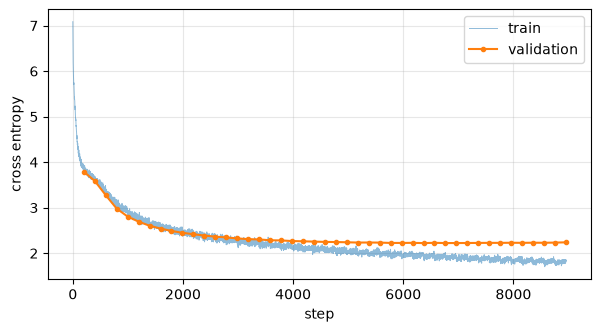

In [17]:
steps, validation = zip(*history['validation'])

plt.figure(figsize=(7, 3.5))
plt.plot(history['train'], linewidth=0.7, alpha=0.5, label='train')
plt.plot(steps, validation, marker='o', markersize=3, label='validation')
plt.xlabel('step')
plt.ylabel('cross entropy')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Generation

In [18]:
@torch.no_grad()
def generate(prompt: str, temperature: float = 0.8, top_k: int = 40, max_tokens: int = CONTEXT_WINDOW) -> str:
    model.eval()
    tokens = torch.tensor(tokenizer.encode(prompt), device=DEVICE)

    for _ in range(max_tokens - len(tokens)):
        scores = model(tokens.unsqueeze(0))[0, -1] / temperature
        kept, candidates = scores.topk(top_k)
        tokens = torch.cat((tokens, candidates[torch.multinomial(kept.softmax(dim=-1), 1)]))

    return tokenizer.decode(tokens.tolist()).replace('\n', ' ')

In [19]:
PROMPT = 'In the first half of 2007, the'

for temperature in (0.4, 0.8, 1.2):
    print(f'temperature {temperature}')
    print(generate(PROMPT, temperature=temperature))
    print()

temperature 0.4


In the first half of 2007, the government has granted the fiscal deficit to 2.5% of GDP, which has been the same as in 2006. The fiscal deficit of 2006 was equivalent to 2.5% of GDP, equivalent to 1.5% of GDP, which is 5.9% more than the previous year’s level. The government is expected to reach 3.5% of GDP, which is attributable to the reduction in the deficit on the income account and the fiscal deficit. The fiscal deficit is projected to be US$ 2.2 billion, or 0.8% of GDP, compared to 2.6% in 2006. The government’s primary surplus is expected to increase in 2007, as a result of a rise in the tax base and the tax on the profits, which is expected to rise by 1.5% in 2006. The government’s fiscal deficit narrowed from

temperature 0.8


In the first half of 2007, the region’s economic performance has been a major excellent than in 2007. The economic crisis, including both domestic and external demand, measures were up by 24.2%, after having appreciated by 4.5% again in 2006. In 2007, the fiscal deficit stood at 7.7% of GDP (0.1% in 2006), in nominal terms, thanks to an increase in the surplus on the non-financial public debt, an increase in the tax burden, and the tax reform, to the extent of the fiscal deficit. The government placed a new regime for the latter caused on revenue from tax on non-tax revenue, which received a higher tax selected increase in transfers and a widening of the tax structure of the economy. The tax reform proposed the execut

temperature 1.2


In the first half of 2007, the level of economic activity has been rising since the beginning of 2009. The labour participation rate (which has also been dynamism, but the five countries that recorded higher than those for those years and those of Asia and a rearing of the 9% return on the current preceding period of the 1990s. Given this heterogeneous trend, the unemployment rate is lower than 90% per annum, thereby helping to come to lower the middle class, which in turn reflected weakening from 1985, pushed inflation eased to narrowing from seasonal trends in several factors which include losses stagnated in keeping economic variables. (Guyana) Round Weighted average rate, and there has been rising faster than in the rest of the



### Attention maps

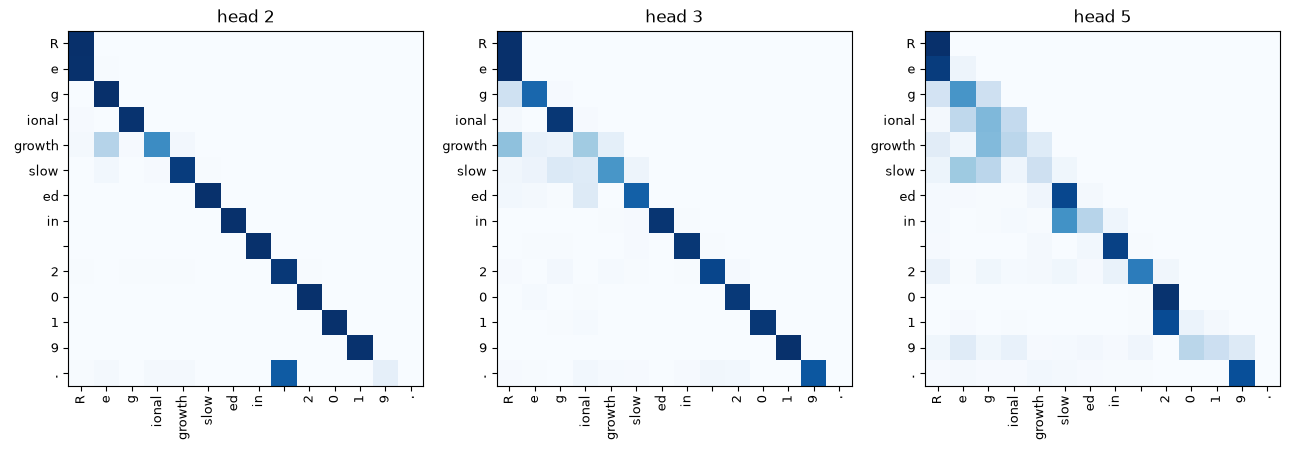

In [20]:
SHORT = 'Regional growth slowed in 2019.'


@torch.no_grad()
def attention_maps(text: str, layer: int) -> torch.Tensor:
    model.eval()
    model(torch.tensor(tokenizer.encode(text), device=DEVICE).unsqueeze(0))
    return torch.stack([head.attention[0] for head in model.blocks[layer].attention.heads]).cpu()


maps = attention_maps(SHORT, layer=0)
labels = [tokenizer.decode([token_id]) for token_id in tokenizer.encode(SHORT)]

# The three heads whose attention is most concentrated, which are the ones with a pattern to see.
entropy = -(maps * maps.clamp(min=1e-9).log()).sum(-1).mean(-1)
chosen = entropy.argsort()[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, head in zip(axes, chosen):
    ax.imshow(maps[head], cmap='Blues')
    ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=9)
    ax.set_yticks(range(len(labels)), labels, fontsize=9)
    ax.set_title(f'head {head + 1}')
plt.tight_layout()
plt.show()

## 3. Pre-training and post-training

In [21]:
from datasets import load_dataset
from huggingface_hub.utils import logging as hub_logging
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as transformers_logging

hub_logging.set_verbosity_error()
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()

CHAT_MODEL = 'Qwen/Qwen2.5-7B-Instruct'

chat_tokenizer = AutoTokenizer.from_pretrained(CHAT_MODEL)
chat_model = AutoModelForCausalLM.from_pretrained(CHAT_MODEL, dtype=torch.bfloat16).to(DEVICE).eval()

print(f'{CHAT_MODEL}: {sum(p.numel() for p in chat_model.parameters()) / 1e9:.1f} billion parameters')

Qwen/Qwen2.5-7B-Instruct: 7.6 billion parameters


### What the model receives

In [22]:
conversation = [
    {'role': 'system', 'content': 'You answer questions about ECLAC statistics.'},
    {'role': 'user', 'content': 'Which report publishes poverty by country?'},
]

prompt = chat_tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
print(prompt)

<|im_start|>system
You answer questions about ECLAC statistics.<|im_end|>
<|im_start|>user
Which report publishes poverty by country?<|im_end|>
<|im_start|>assistant



In [23]:
for token_id in chat_tokenizer(prompt).input_ids[:12]:
    print(f'{token_id:>7}  {chat_tokenizer.decode([token_id])!r}')

 151644  '<|im_start|>'
   8948  'system'
    198  '\n'
   2610  'You'
   4226  ' answer'
   4755  ' questions'
    911  ' about'
    468  ' E'
   3140  'CL'
   1706  'AC'
  13142  ' statistics'
     13  '.'


### Instruction following data

In [24]:
alpaca = load_dataset('tatsu-lab/alpaca', split='train')

print(f'tatsu-lab/alpaca: {thousands(len(alpaca))} examples')
print()
for field, text in alpaca[3].items():
    if text:
        print(f'{field}: {text}')

tatsu-lab/alpaca: 52 002 examples

instruction: How can we reduce air pollution?
output: There are a number of ways to reduce air pollution, such as shifting to renewable energy sources, encouraging the use of public transportation, prohibiting the burning of fossil fuels, implementing policies to reduce emissions from industrial sources, and implementing vehicle emissions standards. Additionally, individuals can do their part to reduce air pollution by reducing car use, avoiding burning materials such as wood, and changing to energy efficient appliances.
text: Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
How can we reduce air pollution?

### Response:
There are a number of ways to reduce air pollution, such as shifting to renewable energy sources, encouraging the use of public transportation, prohibiting the burning of fossil fuels, implementing policies to reduce emissions from industrial sources, and impl

### Alignment data

In [25]:
preferences = load_dataset('HuggingFaceH4/ultrafeedback_binarized', split='train_prefs')
pair = min(preferences.select(range(200)), key=lambda row: len(row['prompt']))

print(f'HuggingFaceH4/ultrafeedback_binarized: {thousands(len(preferences))} pairs')
print()
print(f"prompt: {pair['prompt'][:200]}")
print()
for field in ('chosen', 'rejected'):
    print(f"{field}: {pair[field][-1]['content'][:240]}")
    print()

HuggingFaceH4/ultrafeedback_binarized: 61 135 pairs

prompt: How to paint literature?

chosen: I believe you might be looking for suggestions on how to "paint with words" or to create a literary work that is rich and vivid, like a painting. Here's how you can do that:

1. Use descriptive language: This is the most obvious tip, but it

rejected: Thank you for reaching out! I'm here to help you with any questions you may have. However, I must inform you that painting literature is not a feasible or practical task, as literature is a form of written or printed works, rather than a ph



## 4. Scale, reasoning and evaluation

### Zero shot and few shot

In [26]:
BASE_MODEL = 'openai-community/gpt2-xl'

base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.bfloat16).to(DEVICE).eval()

QUESTION = 'What is the capital of Chile?'
ZERO_SHOT = QUESTION
FEW_SHOT = f'Question: What is the capital of France?\nAnswer: Paris.\n\nQuestion: What is the capital of Japan?\nAnswer: Tokyo.\n\nQuestion: {QUESTION}\nAnswer:'


@torch.no_grad()
def continue_text(prompt: str, max_new_tokens: int = 12) -> str:
    tokens = base_tokenizer(prompt, return_tensors='pt').to(DEVICE)
    written = base_model.generate(**tokens, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=base_tokenizer.eos_token_id)
    answer = base_tokenizer.decode(written[0, tokens.input_ids.shape[1]:], skip_special_tokens=True)
    return answer.strip().splitlines()[0] if answer.strip() else ''


print(f'{BASE_MODEL}')
print(f'  zero shot: {continue_text(ZERO_SHOT)!r}')
print(f'  few shot:  {continue_text(FEW_SHOT)!r}')

openai-community/gpt2-xl


  zero shot: 'Chile is the capital of Chile.'


  few shot:  'Santiago.'


In [27]:
@torch.no_grad()
def ask(question: str, max_new_tokens: int = 64) -> str:
    prompt = chat_tokenizer.apply_chat_template([{'role': 'user', 'content': question}], tokenize=False, add_generation_prompt=True)
    tokens = chat_tokenizer(prompt, return_tensors='pt').to(DEVICE)
    written = chat_model.generate(**tokens, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=chat_tokenizer.eos_token_id)
    return chat_tokenizer.decode(written[0, tokens.input_ids.shape[1]:], skip_special_tokens=True).strip()


print(f'{CHAT_MODEL}')
print(f'  zero shot: {ask(QUESTION)!r}')

Qwen/Qwen2.5-7B-Instruct


  zero shot: 'The capital of Chile is Santiago.'


### Reasoning

In [28]:
REASONING_MODEL = 'Qwen/Qwen3-8B'

del base_model
torch.cuda.empty_cache()

reasoning_tokenizer = AutoTokenizer.from_pretrained(REASONING_MODEL)
reasoning_model = AutoModelForCausalLM.from_pretrained(REASONING_MODEL, dtype=torch.bfloat16).to(DEVICE).eval()

PUZZLE = 'Poverty was 12% in 2019 and 8% in 2023. By how many percentage points did it fall?'
BUDGET = 2500


@torch.no_grad()
def think(question: str) -> str:
    prompt = reasoning_tokenizer.apply_chat_template([{'role': 'user', 'content': question}], tokenize=False, add_generation_prompt=True, enable_thinking=True)
    tokens = reasoning_tokenizer(prompt, return_tensors='pt').to(DEVICE)
    written = reasoning_model.generate(**tokens, max_new_tokens=BUDGET, do_sample=False, pad_token_id=reasoning_tokenizer.eos_token_id)

    new_tokens = written[0, tokens.input_ids.shape[1]:]
    print(f'{len(new_tokens)} tokens generated of {BUDGET} allowed')
    return reasoning_tokenizer.decode(new_tokens, skip_special_tokens=False)


answer = think(PUZZLE)
print(answer.replace('<think>', '\n<think>\n').replace('</think>', '\n</think>\n'))

865 tokens generated of 2500 allowed

<think>

Okay, so I need to figure out by how many percentage points poverty fell from 2019 to 2023. Let me start by recalling what percentage points mean. I think percentage points are different from percent change. For example, if something goes from 10% to 15%, that's an increase of 5 percentage points, but the percent change would be different. So in this case, the poverty rate went from 12% in 2019 to 8% in 2023. 

So, to find the decrease in percentage points, I just subtract the two percentages, right? Let me check that. If it was 12% and then 8%, then the difference is 12 minus 8. That would be 4. So, is it 4 percentage points? That seems straightforward. But wait, maybe I need to verify if there's a trick here. 

Let me think again. Percentage points are absolute differences, whereas percent change is relative. So if someone asks by what percentage it decreased, that would be different. But the question specifically says "by how many perce

### Evaluating a model

In [29]:
gsm8k = load_dataset('openai/gsm8k', 'main', split='test')
item = min(gsm8k, key=lambda row: len(row['question']))

print(f'openai/gsm8k: {thousands(len(gsm8k))} test problems')
print()
print(f"question: {item['question']}")
print(f"reference: {item['answer'].split('####')[-1].strip()}")

openai/gsm8k: 1 319 test problems

question: Ali had $21. Leila gave him half of her $100. How much does Ali have now?
reference: 71


In [30]:
written = ask(item['question'], max_new_tokens=320)
found = re.findall(r'-?\d+(?:\.\d+)?', written.replace(',', ''))

print(written)
print()
print(f"extracted: {found[-1] if found else 'nothing'}   reference: {item['answer'].split('####')[-1].strip()}")

Let's break down the problem step by step:

1. Ali initially has $21.
2. Leila has $100 and gives Ali half of it. Half of $100 is calculated as:
   \[
   \frac{100}{2} = 50
   \]
3. So, Leila gives Ali $50.

Now, we add the $50 that Leila gave to Ali's initial amount of $21:
\[
21 + 50 = 71
\]

Therefore, Ali now has $71.

extracted: 71   reference: 71


### Freeing the GPU

In [31]:
del model, chat_model, reasoning_model
torch.cuda.empty_cache()

print(f'{torch.cuda.memory_allocated() / 1e9:.2f} GB still held on the GPU')


0.08 GB still held on the GPU
